# pandas wrap-up

In [1]:
import numpy as np
import pandas as pd

In [2]:
rowdata = {'col1': [414, 651], 'col2': [715, 612]}
areacodes = pd.DataFrame(rowdata, index = ['WI', 'MN'])
areacodes['col3'] = [262, 218]

areacodes

,col1,col2,col3
WI,414,715,262
MN,651,612,218


In [3]:
areacodes.index

Index(['WI', 'MN'], dtype='object')

In [4]:
areacodes.index = areacodes['col1']

areacodes

,col1,col2,col3
col1,,,
414,414,715,262
651,651,612,218


In [5]:
areacodes.index

Index([414, 651], dtype='int64', name='col1')

In [6]:
orchard_output = areacodes
orchard_output.columns = ['apples', 'cherries', 'strawberries']
orchard_output

,apples,cherries,strawberries
col1,,,
414,414,715,262
651,651,612,218


In [7]:
orchard_output['State'] = ['WI', 'MN']
orchard_output

,apples,cherries,strawberries,State
col1,,,,
414,414,715,262,WI
651,651,612,218,MN


In [8]:
orchard_output.set_index('State')  # also removes the column from the set of columns

# also could use:
# orchart_output.index = 

,apples,cherries,strawberries
State,,,
WI,414,715,262
MN,651,612,218


In [9]:
orchard_output.groupby('apples').sum()    # returns a new DataFrame, with an index of Apples

,cherries,strawberries,State
apples,,,
414,715,262,WI
651,612,218,MN


In [10]:
o = orchard_output

In [11]:
o.set_index('State', inplace=True)

In [12]:
o

,apples,cherries,strawberries
State,,,
WI,414,715,262
MN,651,612,218


In [13]:
o['Total Orchard Output'] = o['apples'] + o['cherries'] + o['strawberries']
o

,apples,cherries,strawberries,Total Orchard Output
State,,,,
WI,414,715,262,1391
MN,651,612,218,1481


In [14]:
o.groupby('Total Orchard Output')[['apples']].mean()

,apples
Total Orchard Output,
1391,414.0
1481,651.0


## examples using Northwind

In [15]:
nw = pd.read_csv("northwind_example.csv")
nw

,OrderID,ProductName,UnitPrice,Quantity
0,10248,Queso Cabrales,14.0,12
1,10248,Singaporean Hokkien Fried Mee,9.8,10
2,10248,Mozzarella di Giovanni,34.8,5
3,10249,Manjimup Dried Apples,42.4,40
4,10249,Tofu,18.6,9
...,...,...,...,...
495,10435,Mozzarella di Giovanni,27.8,10
496,10436,Gnocchi di nonna Alice,30.4,40
497,10436,Wimmers gute Semmelkndel,26.6,30
498,10436,Rhnbru Klosterbier,6.2,24


## Which product is the highest selling, by # of orders? Which is the lowest selling?

In [16]:
nw.groupby("OrderID")[['ProductName']].count()   # wrong way around!

,ProductName
OrderID,
10248,3
10249,2
10250,3
10251,3
10252,3
...,...
10432,2
10433,1
10434,2


In [17]:
top_selling = nw.groupby("ProductName")[['OrderID']].agg('count').sort_values('OrderID', ascending=False)   # aggregation function lets you build a more complex set of aggregations

# nw.groupby("ProductName")[['OrderID']].count().sort_values('OrderID')      # same result as above

top_selling.columns = ['Order Count']

top_selling

,Order Count
ProductName,
Mozzarella di Giovanni,14
Raclette Courdavault,14
Gorgonzola Telino,14
Flotemysost,13
Tarte au sucre,13
...,...
Laughing Lumberjack Lager,1
Chocolade,1
Louisiana Hot Spiced Okra,1


In [18]:
top_selling.head(3)

,Order Count
ProductName,
Mozzarella di Giovanni,14
Raclette Courdavault,14
Gorgonzola Telino,14


In [19]:
top_selling[(top_selling['Order Count'] == 1)]

,Order Count
ProductName,
Sirop d'rable,1
Rogede sild,1
Laughing Lumberjack Lager,1
Chocolade,1
Louisiana Hot Spiced Okra,1
Queso Manchego La Pastora,1
Mishi Kobe Niku,1


## What was total revenue? What was line-item revenue? What was revenue by product?

In [20]:
nw['LineTotal'] = nw['UnitPrice'] * nw['Quantity']
nw

,OrderID,ProductName,UnitPrice,Quantity,LineTotal
0,10248,Queso Cabrales,14.0,12,168.0
1,10248,Singaporean Hokkien Fried Mee,9.8,10,98.0
2,10248,Mozzarella di Giovanni,34.8,5,174.0
3,10249,Manjimup Dried Apples,42.4,40,1696.0
4,10249,Tofu,18.6,9,167.4
...,...,...,...,...,...
495,10435,Mozzarella di Giovanni,27.8,10,278.0
496,10436,Gnocchi di nonna Alice,30.4,40,1216.0
497,10436,Wimmers gute Semmelkndel,26.6,30,798.0
498,10436,Rhnbru Klosterbier,6.2,24,148.8


In [21]:
prod_by_rev = nw.groupby('ProductName')[['Quantity', 'LineTotal']].sum()
prod_by_rev.columns = ['Total Qty Sold', 'Total Product Revenue']
prod_by_rev

,Total Qty Sold,Total Product Revenue
ProductName,,
Alice Mutton,331,10327.2
Aniseed Syrup,80,640.0
Boston Crab Meat,256,3763.2
Camembert Pierrot,430,11696.0
Carnarvon Tigers,106,5300.0
...,...,...
Uncle Bob's Organic Dried Pears,25,600.0
Valkoinen suklaa,70,910.0
Vegie-spread,209,7335.9


In [22]:
prod_by_rev['Total Product Revenue'].sum() 

297044.9

In [23]:
nw['LineTotal'].sum()

297044.9

In [24]:
prod_by_rev.sort_index(ascending=False)

,Total Qty Sold,Total Product Revenue
ProductName,,
Zaanse koeken,101,767.6
Wimmers gute Semmelkndel,161,4282.6
Vegie-spread,209,7335.9
Valkoinen suklaa,70,910.0
Uncle Bob's Organic Dried Pears,25,600.0
...,...,...
Carnarvon Tigers,106,5300.0
Camembert Pierrot,430,11696.0
Boston Crab Meat,256,3763.2


In [25]:
nw.sort_index(axis='columns')

,LineTotal,OrderID,ProductName,Quantity,UnitPrice
0,168.0,10248,Queso Cabrales,12,14.0
1,98.0,10248,Singaporean Hokkien Fried Mee,10,9.8
2,174.0,10248,Mozzarella di Giovanni,5,34.8
3,1696.0,10249,Manjimup Dried Apples,40,42.4
4,167.4,10249,Tofu,9,18.6
...,...,...,...,...,...
495,278.0,10435,Mozzarella di Giovanni,10,27.8
496,1216.0,10436,Gnocchi di nonna Alice,40,30.4
497,798.0,10436,Wimmers gute Semmelkndel,30,26.6
498,148.8,10436,Rhnbru Klosterbier,24,6.2


In [26]:
nw.sort_values('Quantity', ascending=False).head(10)

,OrderID,ProductName,UnitPrice,Quantity,LineTotal
399,10398,Pt chinois,19.2,120,2304.0
102,10286,Steeleye Stout,14.4,100,1440.0
295,10359,Camembert Pierrot,27.2,80,2176.0
196,10324,Vegie-spread,35.1,80,2808.0
334,10373,Escargots de Bourgogne,10.6,80,848.0
260,10345,Teatime Chocolate Biscuits,7.3,80,584.0
274,10351,Gula Malacca,15.5,77,1193.5
330,10372,Camembert Pierrot,27.2,70,1904.0
52,10267,Raclette Courdavault,44.0,70,3080.0
296,10359,Gorgonzola Telino,10.0,70,700.0


In [27]:
# using rank

qty = nw[['Quantity']].rank(axis='rows')
nw.insert(4, 'Ranking by qty ordered', qty)
nw

,OrderID,ProductName,UnitPrice,Quantity,Ranking by qty ordered,LineTotal
0,10248,Queso Cabrales,14.0,12,142.5,168.0
1,10248,Singaporean Hokkien Fried Mee,9.8,10,108.5,98.0
2,10248,Mozzarella di Giovanni,34.8,5,35.5,174.0
3,10249,Manjimup Dried Apples,42.4,40,413.5,1696.0
4,10249,Tofu,18.6,9,82.5,167.4
...,...,...,...,...,...,...
495,10435,Mozzarella di Giovanni,27.8,10,108.5,278.0
496,10436,Gnocchi di nonna Alice,30.4,40,413.5,1216.0
497,10436,Wimmers gute Semmelkndel,26.6,30,355.5,798.0
498,10436,Rhnbru Klosterbier,6.2,24,302.5,148.8


In [28]:
prod_by_rev

,Total Qty Sold,Total Product Revenue
ProductName,,
Alice Mutton,331,10327.2
Aniseed Syrup,80,640.0
Boston Crab Meat,256,3763.2
Camembert Pierrot,430,11696.0
Carnarvon Tigers,106,5300.0
...,...,...
Uncle Bob's Organic Dried Pears,25,600.0
Valkoinen suklaa,70,910.0
Vegie-spread,209,7335.9


In [29]:
# prod_rank = prod_by_rev[['Total Product Revenue']].rank(axis='columns')
# prod_rank.columns = ['Product Rank']
# prod_rank   # this result looks weird but we're going to pretend it's fine

prod_rank = prod_by_rev[['Total Product Revenue']].rank(axis='rows')   # by rows!! not columns!!
prod_rank.columns = ['Product Rank']
prod_rank

,Product Rank
ProductName,
Alice Mutton,72.0
Aniseed Syrup,14.0
Boston Crab Meat,51.0
Camembert Pierrot,73.0
Carnarvon Tigers,61.0
...,...
Uncle Bob's Organic Dried Pears,12.0
Valkoinen suklaa,22.0
Vegie-spread,69.0


In [30]:
nw = pd.merge(nw,prod_rank, on='ProductName')

nw

,OrderID,ProductName,UnitPrice,Quantity,Ranking by qty ordered,LineTotal,Product Rank
0,10248,Queso Cabrales,14.0,12,142.5,168.0,43.0
1,10248,Singaporean Hokkien Fried Mee,9.8,10,108.5,98.0,20.0
2,10248,Mozzarella di Giovanni,34.8,5,35.5,174.0,70.0
3,10249,Manjimup Dried Apples,42.4,40,413.5,1696.0,68.0
4,10249,Tofu,18.6,9,82.5,167.4,45.0
...,...,...,...,...,...,...,...
495,10435,Mozzarella di Giovanni,27.8,10,108.5,278.0,70.0
496,10436,Gnocchi di nonna Alice,30.4,40,413.5,1216.0,71.0
497,10436,Wimmers gute Semmelkndel,26.6,30,355.5,798.0,54.0
498,10436,Rhnbru Klosterbier,6.2,24,302.5,148.8,21.0


# Working with matplotlib

In [31]:
import matplotlib.pyplot as plt

In [32]:
byqty = prod_by_rev[['Total Qty Sold']].sort_values('Total Qty Sold', ascending = False)

In [33]:
byqty = byqty.head(10)

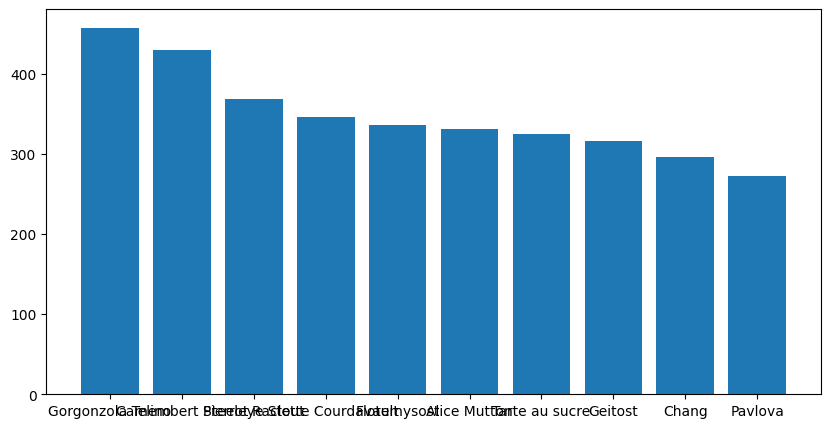

In [37]:
plt.figure(figsize=(10, 5))

plt.bar(byqty.index, byqty['Total Qty Sold'])   # bar is function for creating a column chart; barh creates a horizontal bar chart

plt.show()

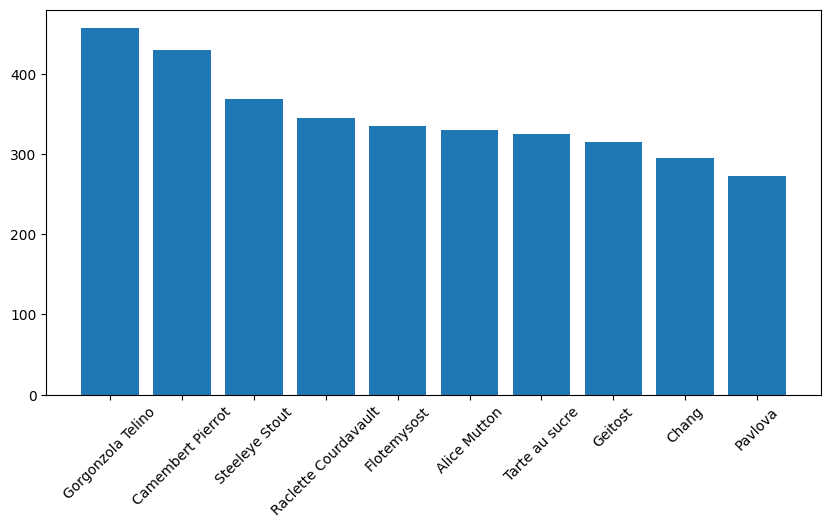

In [45]:
# alternative version

fig, ax = plt.subplots(figsize=(10,5))

plt.xticks(rotation=45)   # quick way to set x-axis label rotation -- fixed

plt.bar(byqty.index, byqty['Total Qty Sold'])

plt.show()

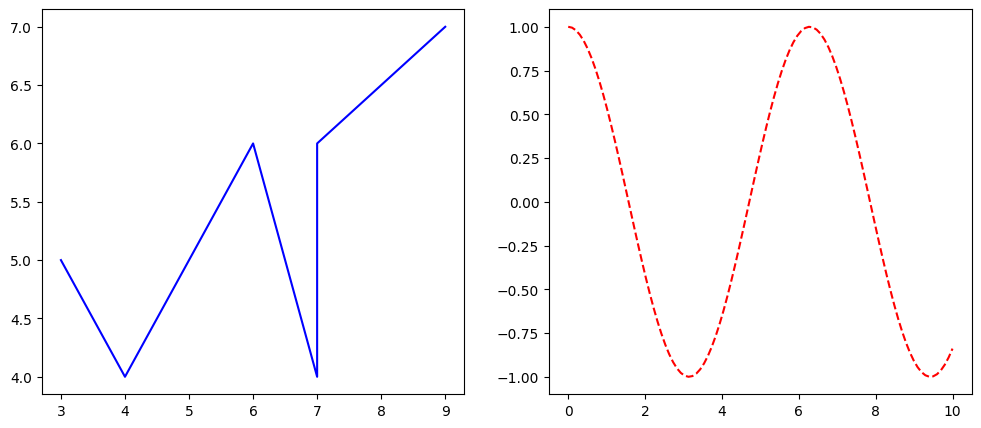

In [44]:
x1 = [3,4,6,7,7,9]
y1 = [5,4,6,4,6,7]
x2 = np.linspace(0, 10, 100)
y2 = np.cos(x2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x1, y1, color='blue', linestyle='-')
axes[1].plot(x2, y2, color='red', linestyle='--')
plt.show()